方法的重写（Override） 和重载（Overload） 是面向对象编程中处理 “同名方法” 的两种核心机制，但 Python 对两者的支持方式差异极大：
- 重写：Python完全支持，是子类对父类方法的“覆盖式定制”；
- 重载：Python无原生语法支持，需要通过其他方式模拟实现。

# 一、重写Override
1. 核心定义：方法重写（也叫 “方法覆盖”）是指：子类重新实现父类中已存在的方法（方法名、参数列表完全一致），覆盖父类的原有逻辑，是实现面向对象 “多态” 的核心方式。
2. 核心特点：
    - 子类方法与父类方法的方法名、参数列表必须完全一致（Python 不强制返回值，但建议保持一致）；
    - 调用子类实例的该方法时，优先执行子类的重写逻辑；
    - 可通过 super() 关键字在子类中调用父类的原方法（保留父类逻辑 + 新增子类逻辑）；
    - 是面向对象 “继承 + 多态” 的核心体现。
3. 案例：

In [1]:
# 父类：动物类
class Animal:
    def speak(self):
        """父类的基础叫声逻辑"""
        return "动物发出叫声"

# 子类1：狗类，重写speak方法
class Dog(Animal):
    def speak(self):
        """子类重写：定制狗的叫声"""
        return "汪汪汪"

# 子类2：猫类，重写并保留父类逻辑
class Cat(Animal):
    def speak(self):
        # 先用super()调用父类的speak方法，再新增子类逻辑
        parent_speak = super().speak()
        return f"{parent_speak} → 喵喵喵"

# 测试：多态体现（不同子类调用同一方法，执行不同逻辑）
animal = Animal()
dog = Dog()
cat = Cat()

print(animal.speak())  # 输出：动物发出叫声
print(dog.speak())     # 输出：汪汪汪（完全重写）
print(cat.speak())     # 输出：动物发出叫声 → 喵喵喵（保留父类+新增）

动物发出叫声
汪汪汪
动物发出叫声 → 喵喵喵


4. 使用场景：
    - 子类需要定制父类的核心逻辑：比如父类的方法逻辑通用，但子类有特殊需求（如不同动物的叫声、不同支付方式的支付逻辑）；
    - 实现 “开闭原则”：父类逻辑稳定，子类通过重写扩展功能，无需修改父类代码；
    - 多态调用：统一调用父类方法名，不同子类自动执行自身重写的逻辑（如上述案例中，无论传入 Dog/Cat，都调用 speak() 方法）。

# 二、重载Overload
1. 方法重载是指：同一个类中定义多个同名方法，但参数列表（参数个数、类型、顺序）不同，调用时 Python 解释器根据传入的参数自动匹配对应的方法。
    - 关键提醒：Python 没有原生支持 这种 “多同名方法” 的重载（因为 Python 是动态类型语言，且不允许同一个作用域下定义多个同名方法 —— 后定义的会覆盖先定义的）。
2. Python中模拟重载的3中方式：
- 方式1:默认参数——给方法参数设置默认值，支持“传不同个数的参数”。

In [2]:
class Calculator:
    # 一个方法支持 1 个或 2 个参数（默认参数模拟重载）
    def add(self, a, b=0):
        return a + b

calc = Calculator()
print(calc.add(10))    # 输出：10（只传1个参数，b用默认值0）
print(calc.add(10,20)) # 输出：30（传2个参数）

10
30


- 方式2:可变参数(*args/**kwargs)——支持专入任意个数、任意类型的参数，在方法内部判断参数形式。

In [3]:
class Calculator:
    def add(self, *args):
        """支持加 2 个数、3 个数、甚至更多"""
        total = 0
        for num in args:
            total += num
        return total

calc = Calculator()
print(calc.add(1,2))      # 输出：3
print(calc.add(1,2,3))    # 输出：6
print(calc.add(1,2,3,4))  # 输出：10

3
6
10


- 方式3:functools.singledispatch（基于参数类型的重载）——Python 标准库提供的装饰器，支持 “根据参数类型匹配不同逻辑”（最接近传统重载）。

In [4]:
from functools import singledispatch

# 基础方法（装饰器指定按第一个参数的类型匹配）
@singledispatch
def process_data(data):
    raise NotImplementedError("不支持该类型的数据处理")

# 重载1：处理字符串类型
@process_data.register(str)
def _(data):
    return f"处理字符串：{data.upper()}"

# 重载2：处理列表类型
@process_data.register(list)
def _(data):
    return f"处理列表：{[x*2 for x in data]}"

# 重载3：处理整数类型
@process_data.register(int)
def _(data):
    return f"处理整数：{data * 10}"

# 测试：根据参数类型自动匹配逻辑
print(process_data("hello"))  # 输出：处理字符串：HELLO
print(process_data([1,2,3]))  # 输出：处理列表：[2,4,6]
print(process_data(5))        # 输出：处理整数：50

处理字符串：HELLO
处理列表：[2, 4, 6]
处理整数：50


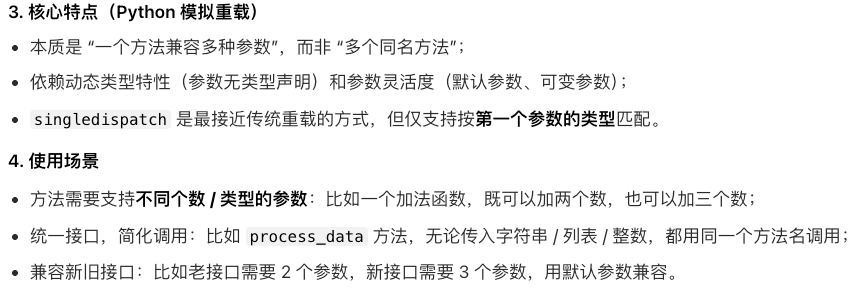
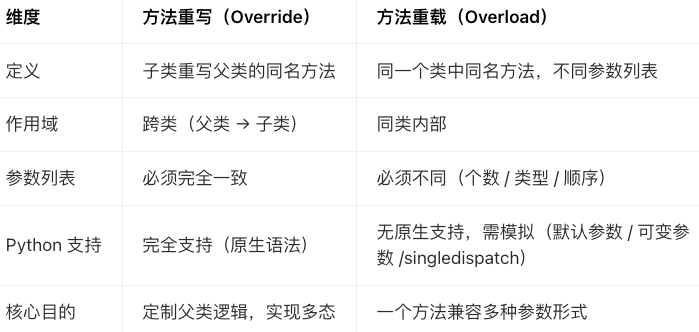